In [1]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import dill
import matplotlib.cm as cm
from matplotlib import colors
from sklearn.metrics.cluster import adjusted_mutual_info_score as ami
from sklearn.metrics.cluster import adjusted_rand_score as ari
import pickle
import sklearn

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print(sklearn.__version__)

1.0.2


In [2]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [16]:
fn = '../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205_nostale.h5ad'

In [17]:
sam=SAM()
sam.load_data(fn)

In [18]:
org = 'xt'

In [19]:
#Find the resolution that has the higest ARI to the mapped clusters
clustering_min = 1
clustering_max = 10
level = 'ss_subclass'

best_ri = 0
t0 = time.time()
all_ri = []
for i in range(clustering_min, clustering_max):
    sam.clustering(param = i/5)
    labeled_data = sam.adata[sam.adata.obs[level] != 'Unlabeled']
    ri = ari(labeled_data.obs[level], labeled_data.obs['leiden_clusters'])
    print(i/5, ri)
    
    if ri > best_ri + .01:
        best_clustering = i/5
        best_ri = ri
    all_ri.append([i/5,ri])
    t1 = time.time()
    print(str(round((i-clustering_min)/clustering_max*100, 2)) + ' percent complete in ' + str(t1 - t0) + ' seconds')

0.2 0.5146731068251527
0.0 percent complete in 1.7790567874908447 seconds
0.4 0.6549524912795982
10.0 percent complete in 3.347975969314575 seconds
0.6 0.7248336692718625
20.0 percent complete in 4.953720569610596 seconds
0.8 0.7507312928825628
30.0 percent complete in 6.546009302139282 seconds
1.0 0.7642913890604203
40.0 percent complete in 8.11349892616272 seconds
1.2 0.7485833647796659
50.0 percent complete in 9.654077291488647 seconds
1.4 0.7101054622330814
60.0 percent complete in 11.188304424285889 seconds
1.6 0.6928517355780881
70.0 percent complete in 12.734821557998657 seconds
1.8 0.6256894860026571
80.0 percent complete in 14.302164077758789 seconds


In [20]:
all_ri = np.array(all_ri)

Text(0.5, 0, 'Clustering Resolution')

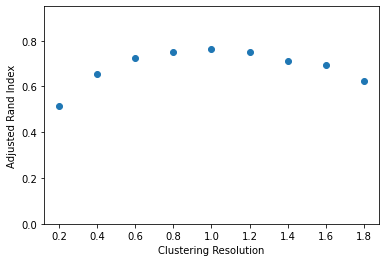

In [21]:
plt.scatter(all_ri[:,0], all_ri[:,1])
plt.ylim(0, .95)
plt.ylabel('Adjusted Rand Index')
plt.xlabel('Clustering Resolution')

In [22]:
level = 'ss_subclass'

In [23]:
best_clustering

1.0

In [24]:
sam.adata[sam.adata.obs[level] == 'Unlabeled']

View of AnnData object with n_obs × n_vars = 10984 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test', 'ss_subclass_old', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn', 'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3', 'Manually_Added', 'ss_subclass_old_manual', 'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_v5_nounlabeled'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    un

In [25]:
level = 'ss_subclass'
unmapped_adata = sam.adata[sam.adata.obs[level] == 'Unlabeled']

In [26]:
sam_unmapped=SAM(unmapped_adata)
sam_unmapped.run()
sam_unmapped.clustering(param = best_clustering)

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.7904363455739237
Iteration: 2, Convergence: 0.011112608861937184
Computing the UMAP embedding...
Elapsed time: 40.987093448638916 seconds


In [27]:
sam_unmapped.adata.obs['leiden_clusters'].unique()

[20, 6, 16, 12, 14, ..., 2, 39, 37, 36, 25]
Length: 40
Categories (40, int64): [0, 1, 2, 3, ..., 36, 37, 38, 39]

In [28]:
np.sort(sam.adata.obs['ss_subclass_v5_nounlabeled'].unique())

array(['009 L2/3 IT PIR-ENTl Glut', '011 L2 IT ENT-po Glut',
       '041 OB-in Frmd7 Gaba', '054 STR Prox1 Lhx6 Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '058 PAL-STR Gaba-Chol', '064 STR-PAL Chst9 Gaba',
       '066 NDB-SI-ant Prdm12 Gaba', '070 LSX Prdm12 Slit2 Gaba',
       '072 LSX Sall3 Lmo1 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '080 CEA-AAA-BST Six3 Sp9 Gaba', '082 CEA-BST Ebf1 Pdyn Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', '086 MPO-ADP Lhx8 Gaba',
       '088 BST Tac2 Gaba', '090 BST-MPN Six3 Nrgn Gaba',
       '091 ARH-PVi Six6 Dopa-Gaba', '092 TMv-PMv Tbx3 Hist-Gaba',
       '093 RT-ZI Gnb3 Gaba', '094 SCH Six6 Cdc14a Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '102 DMH-LHA Gsx1 Gaba', '103 PVHd-DMH Lhx6 Gaba',
       '104 TU-ARH Otp Six6 Gaba', '105 TMd-DMH Foxd2 Gaba',
       '106 

In [94]:
fin_labels = []
new_level = 'ss_subclass_v5_nounlabeled'
for item in sam.adata.obs_names:
    if item in unmapped_adata.obs_names:
        fin_labels.append(org + '_' + str(sam_unmapped.adata.obs.loc[item,'leiden_clusters']))
    else:
        fin_labels.append(sam.adata.obs.loc[item, level])
sam.adata.obs[new_level] = fin_labels

In [95]:
for item in sam.adata.obs[new_level].unique():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'

In [96]:
parent_dict['not hypo'] = 'not hypo'

In [97]:
a = 0
b = 0
c = 0
for item in sam.adata.obs[new_level].unique():
    if item[:3] == org + '_':
        b += 1
    else:
        if parent_dict[parent_dict[item]] == 'hypo':
            a += 1
        else:
            c += 1
print(a,b,c, sam.adata.obs[new_level].nunique())

9 36 18 63


In [98]:
np.sort(np.array(sam.adata.obs[new_level].unique()))

array(['041 OB-in Frmd7 Gaba', '044 OB Dopa-Gaba',
       '045 OB-STR-CTX Inh IMN', '056 Sst Chodl Gaba', '062 STR D2 Gaba',
       '064 STR-PAL Chst9 Gaba', '077 CEA-BST Gal Avp Gaba',
       '086 MPO-ADP Lhx8 Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '105 TMd-DMH Foxd2 Gaba',
       '111 TRS-BAC Sln Glut', '130 LHA Pmch Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '133 PVH-SO-PVa Otp Glut',
       '145 MH Tac2 Glut', '314 CB Granule Glut', '320 Astro-OLF NN',
       '322 Tanycyte NN', '323 Ependymal NN', '326 OPC NN',
       '327 Oligo NN', '330 VLMC NN', '332 SMC NN', '333 Endo NN',
       '337 DC NN', '338 Lymphoid NN', 'dr_0', 'dr_1', 'dr_10', 'dr_11',
       'dr_12', 'dr_13', 'dr_14', 'dr_15', 'dr_16', 'dr_17', 'dr_18',
       'dr_19', 'dr_2', 'dr_20', 'dr_21', 'dr_22', 'dr_23', 'dr_24',
       'dr_25', 'dr_26', 'dr_27', 'dr_28', 'dr_29', 'dr_3', 'dr_30',
       'dr_31', 'dr_32', 'dr_33', 'dr_34', 'dr_35', 'dr_4', 'dr_5',
       'dr_6', 'dr_7', 'd

In [99]:
sam.adata

AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass', 'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled', 'ss_subclass', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn', 'ss_subclass_nounlabeled_nmm_v4_nn_thresh30', 'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3', 'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old', 'ss_subclass_v5_nounlabeled'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [100]:
sam.save_anndata(fn)